In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

#경고 메시지 숨기기
import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path1 = '/content/drive/MyDrive/test_data.csv'
file_path2 = '/content/drive/MyDrive/train_data.csv'
test = pd.read_csv(file_path1)
train = pd.read_csv(file_path2)

Mounted at /content/drive


In [ ]:
na_cols = ['CreditScore', 'AccountLengthYears', 'TenureWithBank', 'InvestmentPortfolioValue', 'CallResponseScore' ]

for col in na_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

cols_to_check = ['MarketingScore', 'ResponsePropensity', 'TermDepositSubscribed']
train = train.dropna(subset=cols_to_check)

fill_cols = ['MarketingScore', 'ResponsePropensity']
for c in fill_cols:
    test[c] = test[c].fillna(train[c].median())

In [ ]:
train = train.drop(columns=["ClientID", "TotalTransactions", "LastContactDay", "LastContactMonth"])
test = test.drop(columns=["ClientID", "TotalTransactions", "LastContactDay", "LastContactMonth"])

In [ ]:
train['JobTitle'] = train['JobTitle'].str.lower().str.strip()
test['JobTitle'] = test['JobTitle'].str.lower().str.strip()

In [ ]:
major_regions=["South","West","North","East","Metro","Central"]
train["Region"]=train["Region"].apply(
    lambda x: x if x in major_regions else "Other")
test["Region"]=test["Region"].apply(
    lambda x: x if x in major_regions else "Other")

In [ ]:
def group_job(job):
    if job in ['management', 'admin', 'technician']:
        return 'high_stable'
    elif job in ['blue-collar', 'services', 'self-employed']:
        return 'mid_stable'
    elif job in ['retired', 'student', 'unemployed', 'entrepreneur']:
        return 'low_stable'
    else:
        return 'unknown'

# 새로운 파생 변수 생성
train['JobGroup'] = train['JobTitle'].apply(group_job)
test['JobGroup'] = test['JobTitle'].apply(group_job)
print(train.groupby('JobGroup')['TermDepositSubscribed'].mean().sort_values(ascending=False))

JobGroup
high_stable    0.334495
mid_stable     0.278752
low_stable     0.278639
Name: TermDepositSubscribed, dtype: float64


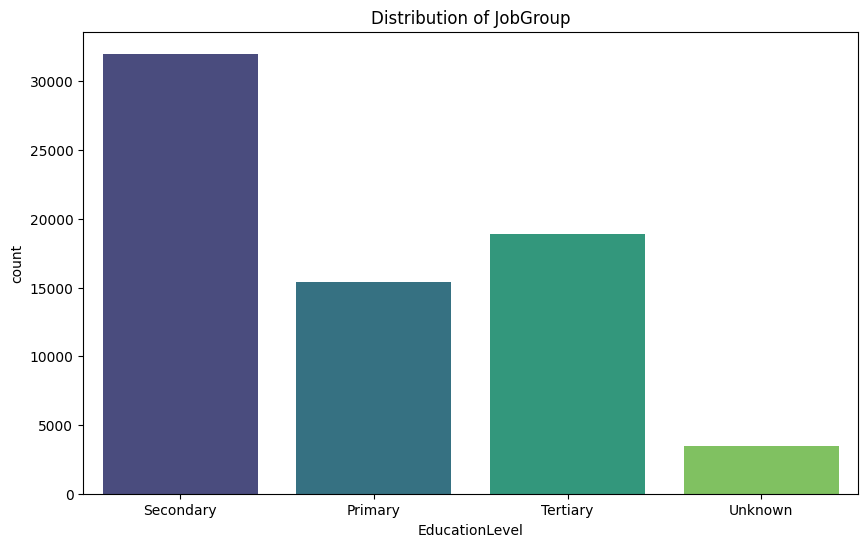

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='EducationLevel', data=train, palette='viridis')
plt.title('Distribution of JobGroup')
plt.show()

In [ ]:
train = train.drop(columns=['JobTitle'], errors='ignore')
test = test.drop(columns=['JobTitle'], errors='ignore')

In [ ]:
# 1. Yes/No 형태의 이진 변수들을 0과 1로 변환
binary_cols = ['HasCreditCard', 'HasMortgage', 'HasPersonalLoan',
               'HasLifeInsurance', 'HasMutualFunds']

for col in binary_cols:
    train[col] = train[col].map({'Yes': 1, 'No': 0})
    test[col] = test[col].map({'Yes': 1, 'No': 0})

# 2. 순서가 있는 변수 (Ordinal Encoding)
edu_map = {'Primary': 0, 'Secondary': 1, 'Tertiary': 2, 'Unknown':1}
train['EducationLevel'] = train['EducationLevel'].map(edu_map)
test['EducationLevel'] = test['EducationLevel'].map(edu_map)

sal_map = {'Low': 0, 'Mid': 1, 'UpperMid': 2, 'High':3}
train['SalaryCategory'] = train['SalaryCategory'].map(sal_map)
test['SalaryCategory'] = test['SalaryCategory'].map(sal_map)

risk_map = {'Low': 0, 'Medium': 1, 'High':2}
train['RiskRating'] = train['RiskRating'].map(risk_map)
test['RiskRating'] = test['RiskRating'].map(risk_map)

# 3. 그 외 범주형 변수 (One-Hot Encoding)
ohe_cols = ['JobGroup', 'MaritalStatus', 'Gender', 'EmploymentStatus', 'Region', 'CustomerSegment', 'ChannelPreference','LastContactChannel', 'PrevCampaignOutcome']
train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
test = pd.get_dummies(test, columns=ohe_cols, drop_first=True)

# 4. 결과 확인
print(train.head())

   Age  EducationLevel  SalaryCategory  AnnualIncome   NetWorth  CreditScore  \
0   38               1               2      73557.65   49265.90        648.0   
1   60               0               1      65795.32   76442.96        673.0   
2   46               2               2     128690.44  101459.38        595.0   
3   52               0               0      27927.95   29529.60        714.0   
4   18               1               0      25631.96   11607.45        588.0   

   CreditLimit  RiskRating  AccountLengthYears  TenureWithBank  ...  \
0     45652.33           1                 6.0             6.0  ...   
1     29628.91           1                 5.0             5.0  ...   
2     54170.59           2                 0.0            12.0  ...   
3     19438.37           1                11.0            13.0  ...   
4     19985.58           2                 2.0             2.0  ...   

   Region_South  Region_West  CustomerSegment_Premium  \
0         False        False       

### 로그변환

In [ ]:
log_cols = [
    'AnnualIncome',
    'NetWorth',
    'CreditLimit',
    'AccountBalance',
    'InvestmentPortfolioValue',
    'AvgTransactionValue',
    'NumOnlineTransactions',
    'NumMobileAppLogins',
    'LastContactDuration'
]

for col in log_cols:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

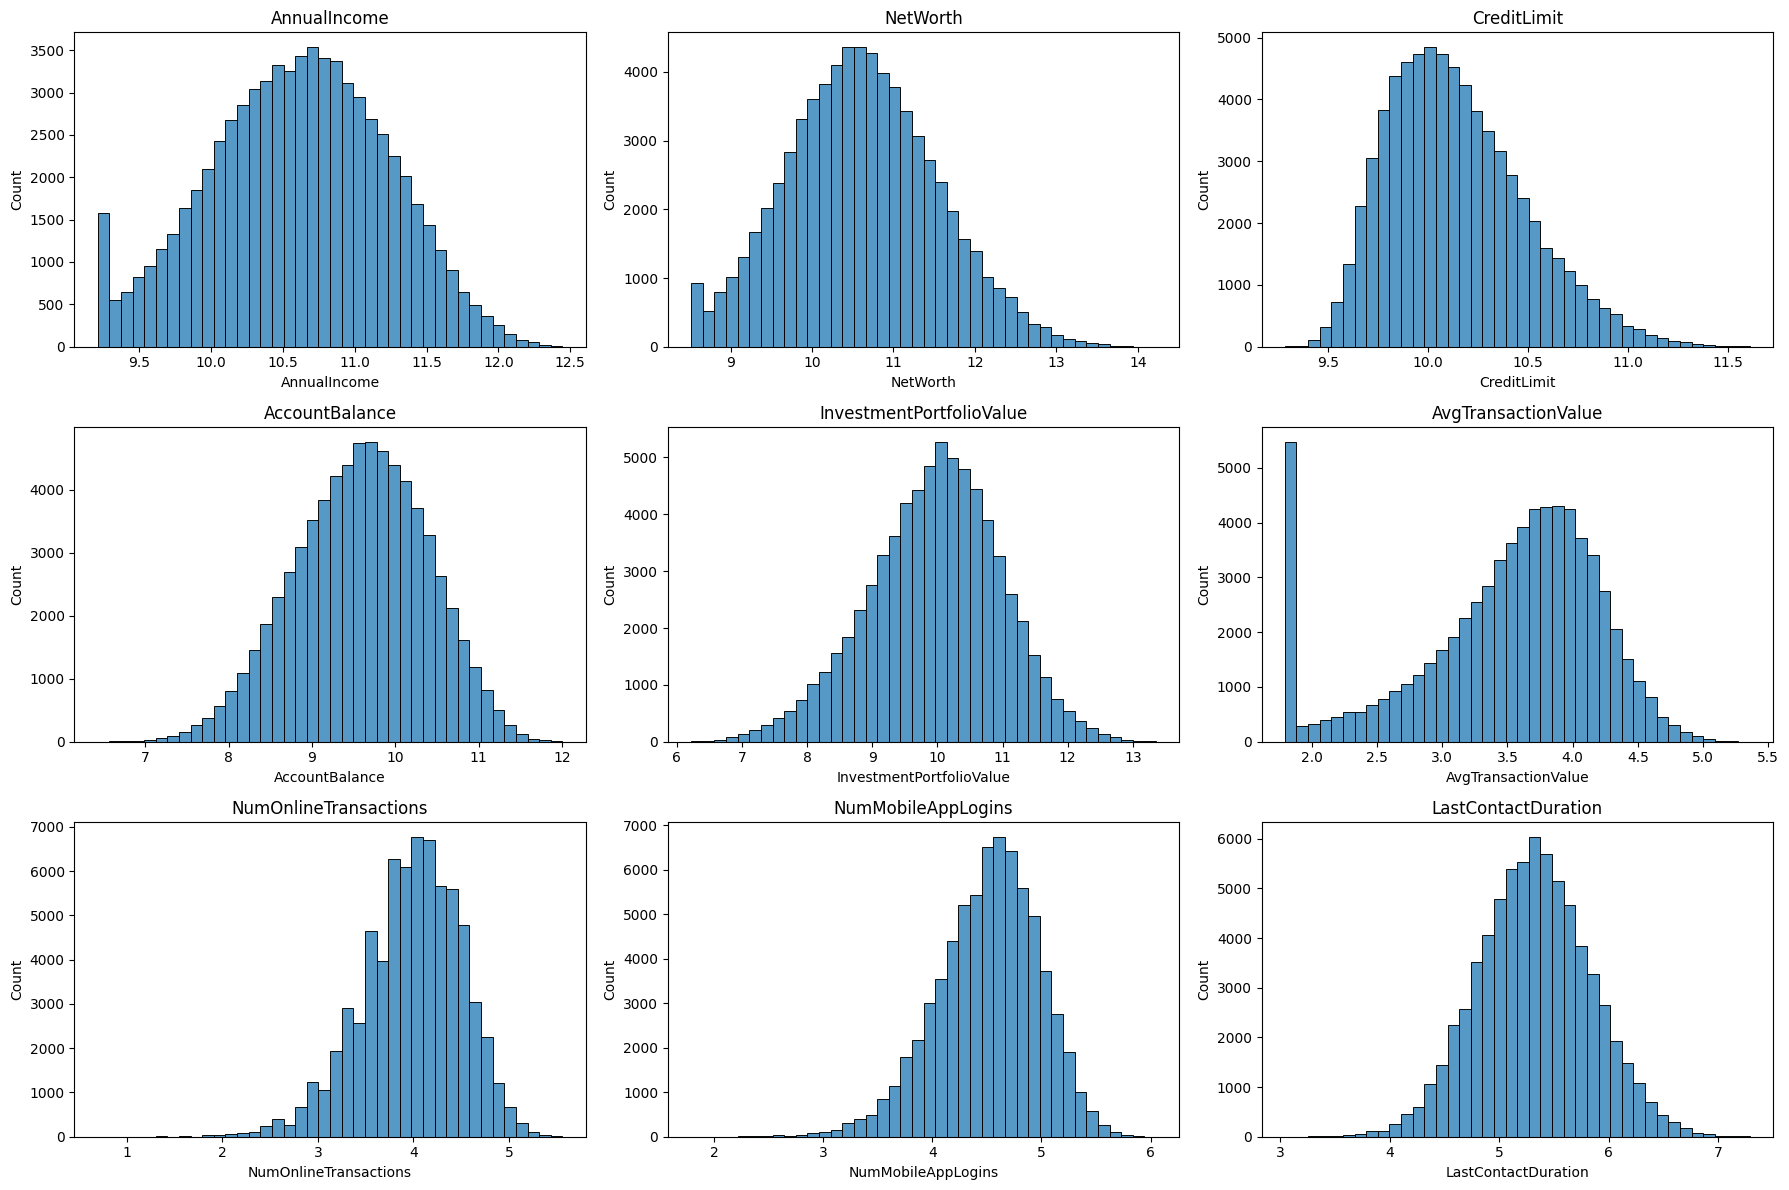

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(log_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, col in enumerate(log_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train[col], bins=40)
    plt.title(col)

plt.tight_layout()
plt.show()


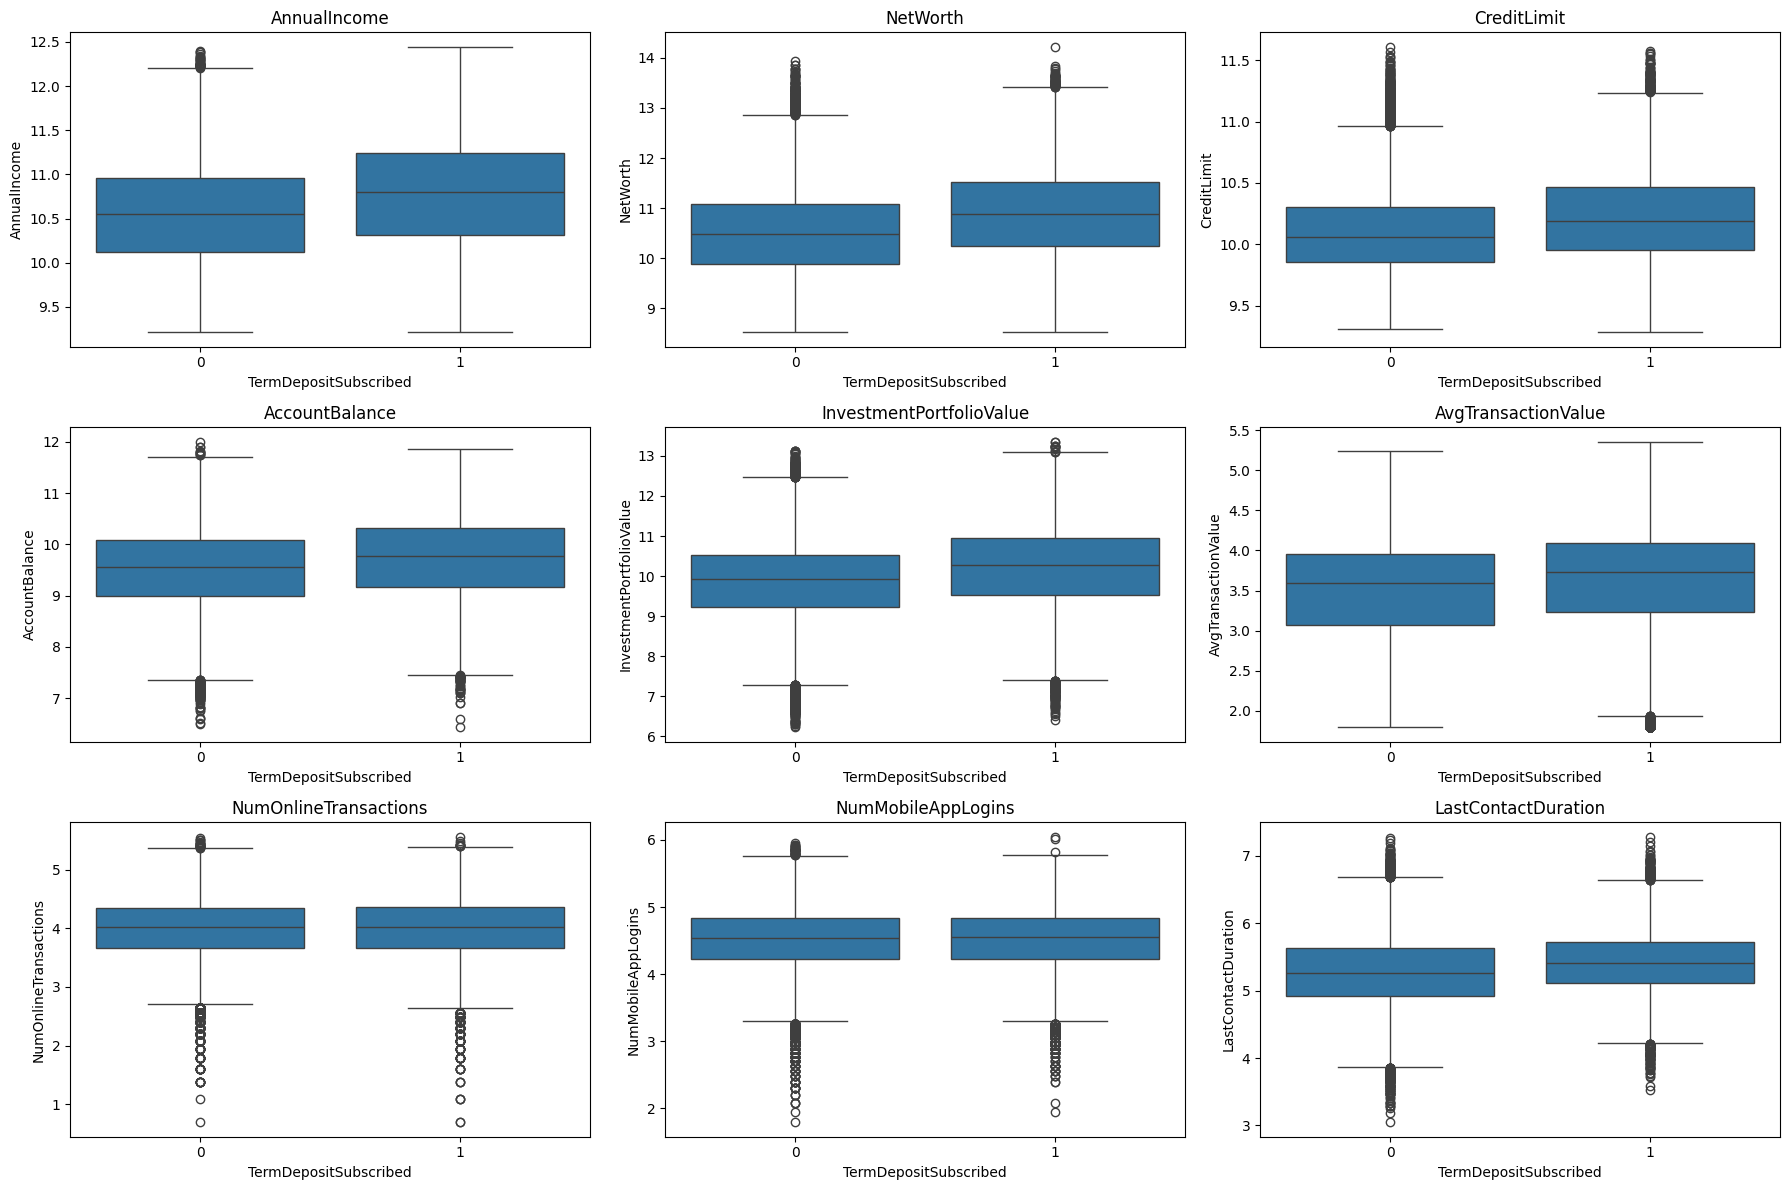

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(log_cols) / n_cols))

plt.figure(figsize=(18, n_rows * 4))

for i, col in enumerate(log_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        x='TermDepositSubscribed',
        y=col,
        data=train
    )
    plt.title(col)

plt.tight_layout()
plt.show()

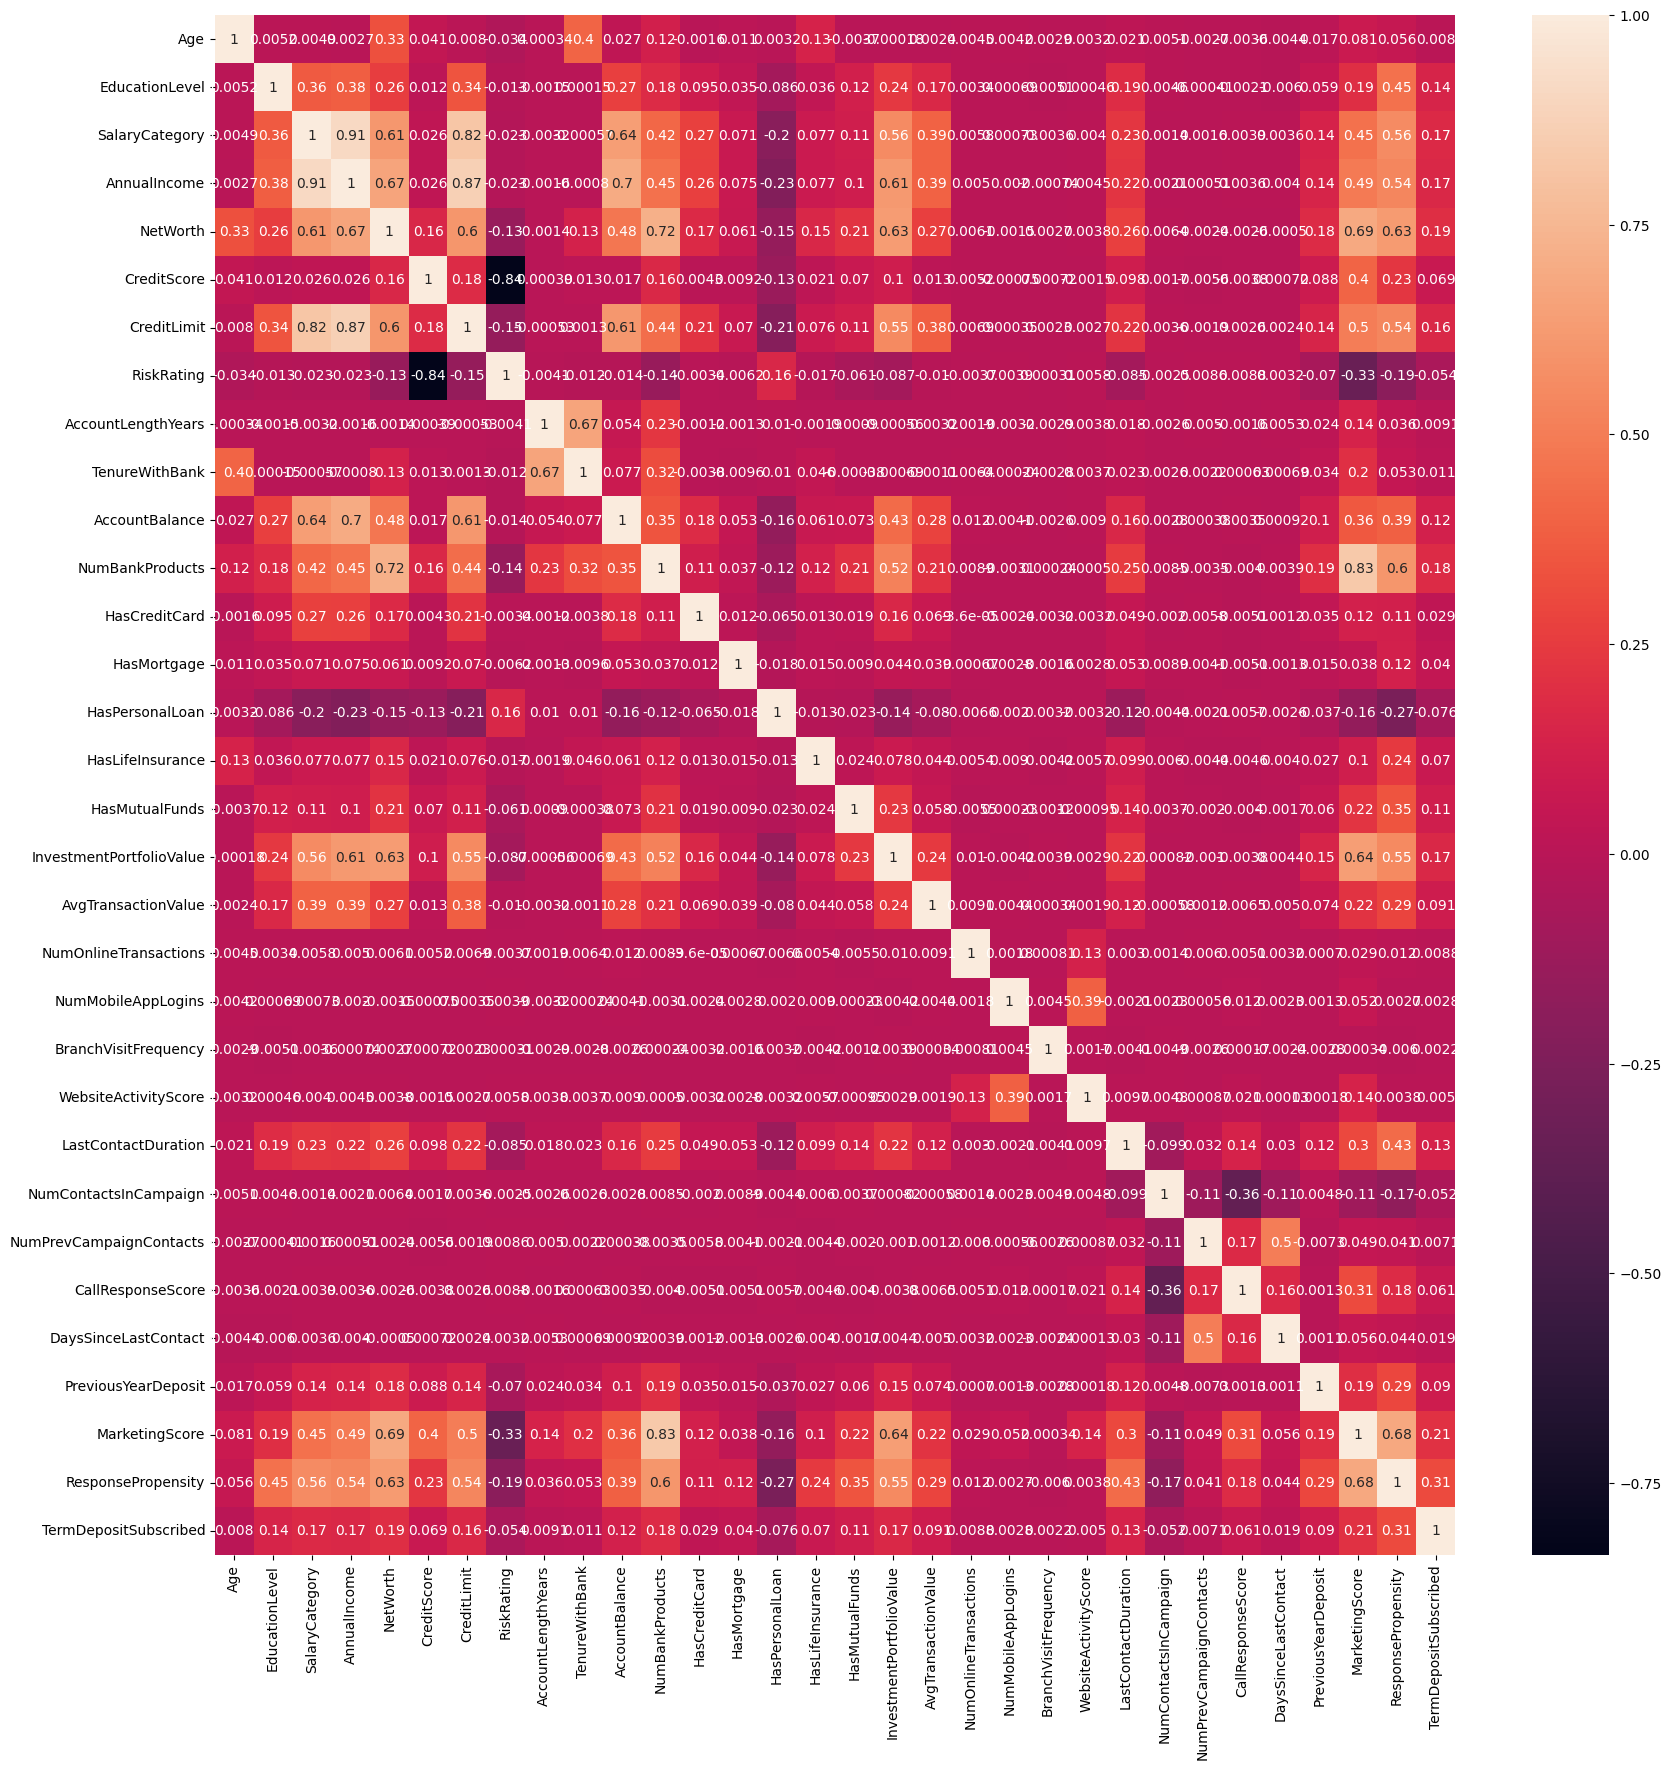

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(data = train.select_dtypes(include=[np.number]).corr(), annot=True)
plt.show()

In [ ]:
import numpy as np

corr = train.select_dtypes(include=[np.number]).corr()

In [ ]:
upper_tri = corr.abs().where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper_tri
    .stack()
    .reset_index()
    .rename(columns={
        "level_0": "Feature_1",
        "level_1": "Feature_2",
        0: "Correlation"
    })
)

high_corr = high_corr[high_corr["Correlation"] >= 0.7] \
                        .sort_values("Correlation", ascending=False)

high_corr

,Feature_1,Feature_2,Correlation
61,SalaryCategory,AnnualIncome,0.908945
92,AnnualIncome,CreditLimit,0.867795
146,CreditScore,RiskRating,0.835658
303,NumBankProducts,MarketingScore,0.834651
64,SalaryCategory,CreditLimit,0.818257
124,NetWorth,NumBankProducts,0.717078


In [ ]:
print(corr.loc["TermDepositSubscribed", "NumBankProducts"])
print(corr.loc["TermDepositSubscribed", "MarketingScore"])
print(corr.loc["TermDepositSubscribed", "NetWorth"])

0.18148911947320662
0.20555202532000322
0.19015308631979064


In [ ]:
train = train.drop(columns=["SalaryCategory", "CreditLimit", "NumBankProducts", "NetWorth"])
test = test.drop(columns=["SalaryCategory", "CreditLimit", "NumBankProducts", "NetWorth"])

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, precision_recall_curve
import numpy as np


# 1. 학습 데이터 및 타겟 분리
X = train.drop(columns=['TermDepositSubscribed'])
y = train['TermDepositSubscribed']
X_test_final = test.copy()


# 2. Train/Validation 세트 분리 (클래스 비율 유지)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# 3. 클래스 불균형 비율 계산 (XGBoost/LightGBM 가중치용)
# '가입 안 함' 대비 '가입 함'의 비율을 계산하여 소수 클래스에 힘을 실어줍니다.
ratio = (y == 0).sum() / (y == 1).sum()


# 4. 개별 모델 정의
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist' # Colab 환경에서 속도 향상
)



lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    scale_pos_weight=ratio,
    random_state=42,
    importance_type='gain'
)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0  # 학습 과정 출력 생략
)

In [ ]:
from sklearn.ensemble import VotingClassifier

# 5. Soft Voting 앙상블 정의 (확률 기반 평균)
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('cat', cat_model)
    ],
    voting='soft'
)

# 6. 모델 학습
print("3중 앙상블 모델 학습 중... (시간이 다소 소요됩니다)")
ensemble_model.fit(X_train, y_train)

# 7. 검증 데이터 확률 추출 및 최적 임계값 찾기
val_probs = ensemble_model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

# F1-Score 계산
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# 정밀도 보강을 위한 임계값 하한선 적용 (최소 0.4 권장)
actual_threshold = max(0.4, best_threshold)

print(f"\n계산된 최적 임계값: {best_threshold:.4f}")
print(f"최종 적용 임계값: {actual_threshold:.4f}")
print(f"최고 Validation F1-Score: {f1_scores[best_idx]:.4f}")

# 8. 최종 성능 리포트
final_val_preds = (val_probs >= actual_threshold).astype(int)
print("\n[최종 앙상블 검증 데이터 성능 리포트]")
print(classification_report(y_val, final_val_preds))

3중 앙상블 모델 학습 중... (시간이 다소 소요됩니다)
[LightGBM] [Info] Number of positive: 16782, number of negative: 39069
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3290
[LightGBM] [Info] Number of data points in the train set: 55851, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300478 -> initscore=-0.845022
[LightGBM] [Info] Start training from score -0.845022
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

In [ ]:
# 4. 테스트 데이터 예측 (이 부분이 y_test_pred를 생성합니다)
# 테스트 데이터 컬럼 순서를 학습 데이터와 동일하게 맞춥니다.
X_test_input = X_test_final.reindex(columns=X.columns, fill_value=0)
test_probs = ensemble_model.predict_proba(X_test_input)[:, 1]
y_test_pred = (test_probs >= actual_threshold).astype(int)

# 5. 제출 파일 저장
file_path3 = '/content/drive/MyDrive/sample_submission_data.csv'
submission = pd.read_csv(file_path3)
submission['TermDepositSubscribed'] = y_test_pred
submission.to_csv('submission_final.csv', index=False)

print("제출 파일이 성공적으로 생성되었습니다!")

제출 파일이 성공적으로 생성되었습니다!
